In [26]:
# Insurance Risk & Pricing Analytics

## Project Objective

# Analyze the factors associated with medical insurance charges
# and develop predictive models for estimating expected insurance costs.

### Technologies
# - Python
# - Pandas
# - NumPy
# - Matplotlib
# - SciPy / Statsmodels
# - Scikit-learn
# - SHAP

In [27]:
## 1. Environment & Data Ingestion

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [29]:
df = pd.read_csv("insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,"16,884.92"
1,18,male,33.77,1,no,southeast,"1,725.55"
2,28,male,33.00,3,no,southeast,"4,449.46"
3,33,male,22.70,0,no,northwest,"21,984.47"
4,32,male,28.88,0,no,northwest,"3,866.86"


In [30]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 1,338
Columns: 7


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [32]:
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [33]:
df.duplicated().sum()

np.int64(1)

In [34]:
for column in ["sex", "smoker", "region"]:
    print(f"\n{column.upper()}")
    print(df[column].value_counts())


SEX
sex
male      676
female    662
Name: count, dtype: int64

SMOKER
smoker
no     1064
yes     274
Name: count, dtype: int64

REGION
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


In [35]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,"1,338.00",39.21,14.05,18.00,27.00,39.00,51.00,64.00
bmi,"1,338.00",30.66,6.10,15.96,26.30,30.40,34.69,53.13
children,"1,338.00",1.09,1.21,0.00,0.00,1.00,2.00,5.00
charges,"1,338.00","13,270.42","12,110.01","1,121.87","4,740.29","9,382.03","16,639.91","63,770.43"


In [36]:
duplicates = df[df.duplicated(keep=False)]

duplicates

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,"1,639.56"
581,19,male,30.59,0,no,northwest,"1,639.56"


In [37]:
duplicates.to_dict("records")

[{'age': 19,
  'sex': 'male',
  'bmi': 30.59,
  'children': 0,
  'smoker': 'no',
  'region': 'northwest',
  'charges': 1639.5631},
 {'age': 19,
  'sex': 'male',
  'bmi': 30.59,
  'children': 0,
  'smoker': 'no',
  'region': 'northwest',
  'charges': 1639.5631}]

In [38]:
df_clean = df.drop_duplicates().copy()

In [39]:
duplicate_count = df.duplicated().sum()

df_clean = df.drop_duplicates().copy()

print(f"Removed {duplicate_count} duplicate row(s).")
print(f"Original records: {len(df):,}")
print(f"Clean records: {len(df_clean):,}")

Removed 1 duplicate row(s).
Original records: 1,338
Clean records: 1,337


In [40]:
validation = {
    "Invalid age": ((df["age"] < 18) | (df["age"] > 100)).sum(),
    "Invalid BMI": ((df["bmi"] <= 0) | (df["bmi"] > 100)).sum(),
    "Invalid children": (df["children"] < 0).sum(),
    "Invalid charges": (df["charges"] <= 0).sum(),
    "Invalid sex": (~df["sex"].isin(["male", "female"])).sum(),
    "Invalid smoker": (~df["smoker"].isin(["yes", "no"])).sum(),
    "Invalid region": (
        ~df["region"].isin(
            ["northeast", "northwest", "southeast", "southwest"]
        )
    ).sum()
}

pd.Series(validation, name="invalid_records")

,invalid_records
Invalid age,0
Invalid BMI,0
Invalid children,0
Invalid charges,0
Invalid sex,0
Invalid smoker,0
Invalid region,0


In [41]:
df_clean = df.drop_duplicates().copy()

print(f"Original rows: {len(df):,}")
print(f"Clean rows:    {len(df_clean):,}")
print(f"Rows removed:  {len(df) - len(df_clean)}")

Original rows: 1,338
Clean rows:    1,337
Rows removed:  1


In [42]:
categorical_cols = ["sex", "smoker", "region"]

for col in categorical_cols:
    print(f"\n{col.upper()}")
    print(df_clean[col].value_counts())
    print("\nPercent:")
    print((df_clean[col].value_counts(normalize=True) * 100).round(2))


SEX
sex
male      675
female    662
Name: count, dtype: int64

Percent:
sex
male     50.49
female   49.51
Name: proportion, dtype: float64

SMOKER
smoker
no     1063
yes     274
Name: count, dtype: int64

Percent:
smoker
no    79.51
yes   20.49
Name: proportion, dtype: float64

REGION
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

Percent:
region
southeast   27.23
southwest   24.31
northwest   24.23
northeast   24.23
Name: proportion, dtype: float64


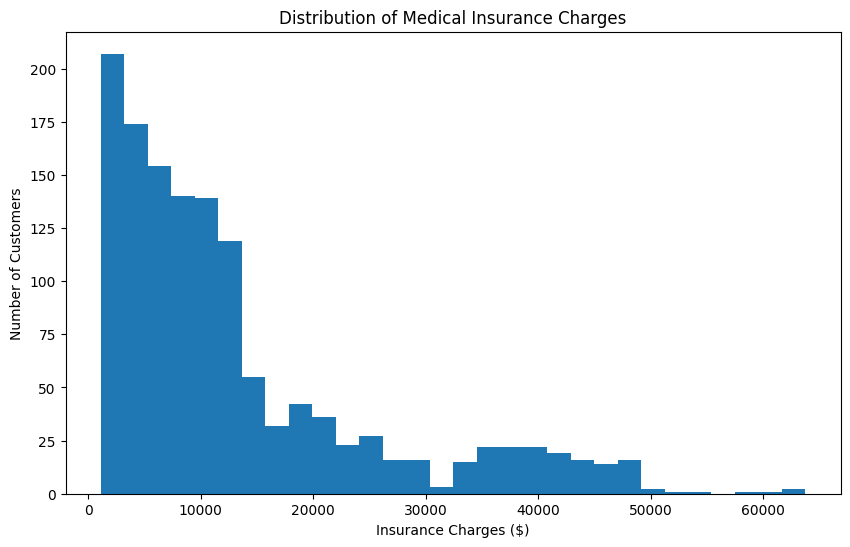

In [43]:
plt.figure(figsize=(10, 6))

plt.hist(df_clean["charges"], bins=30)

plt.title("Distribution of Medical Insurance Charges")
plt.xlabel("Insurance Charges ($)")
plt.ylabel("Number of Customers")

plt.show()

In [44]:
print(f"Mean:   ${df_clean['charges'].mean():,.2f}")
print(f"Median: ${df_clean['charges'].median():,.2f}")
print(f"Skew:   {df_clean['charges'].skew():.2f}")

Mean:   $13,279.12
Median: $9,386.16
Skew:   1.52


In [45]:
df_clean.groupby("smoker")["charges"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(2)

,count,mean,median,std,min,max
smoker,,,,,,
no,1063,"8,440.66","7,345.73","5,992.97","1,121.87","36,910.61"
yes,274,"32,050.23","34,456.35","11,541.55","12,829.46","63,770.43"


<Figure size 800x600 with 0 Axes>

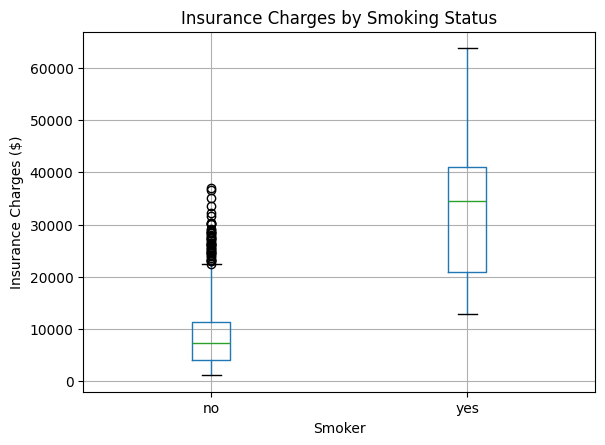

In [46]:
plt.figure(figsize=(8, 6))

df_clean.boxplot(
    column="charges",
    by="smoker"
)

plt.title("Insurance Charges by Smoking Status")
plt.suptitle("")
plt.xlabel("Smoker")
plt.ylabel("Insurance Charges ($)")

plt.show()

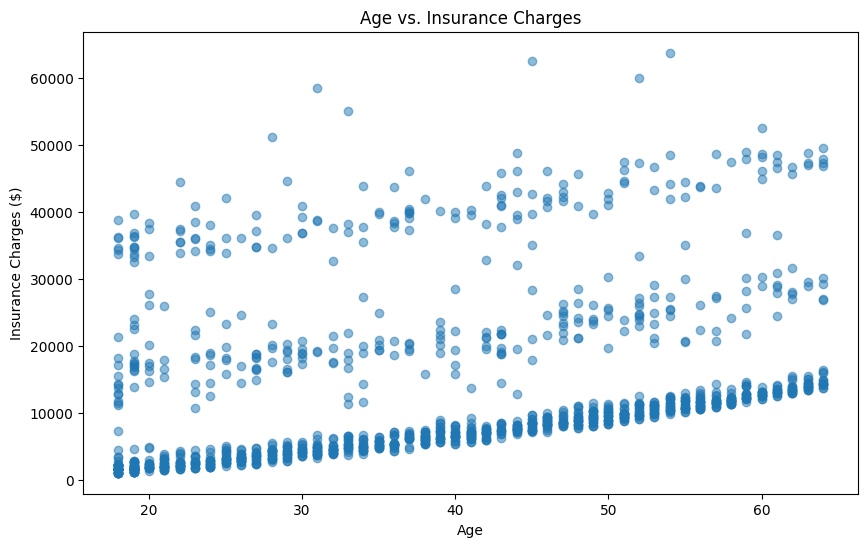

In [47]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_clean["age"],
    df_clean["charges"],
    alpha=0.5
)

plt.title("Age vs. Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Insurance Charges ($)")

plt.show()

In [48]:
df_clean[["age", "bmi", "children", "charges"]].corr().round(3)

,age,bmi,children,charges
age,1.00,0.11,0.04,0.30
bmi,0.11,1.00,0.01,0.20
children,0.04,0.01,1.00,0.07
charges,0.30,0.20,0.07,1.00


In [49]:
df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=[17, 25, 35, 45, 55, 64],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-64"
    ]
)

In [50]:
df_clean["age_group"].value_counts().sort_index()

,count
age_group,
18-25,305
26-35,268
36-45,264
46-55,284
56-64,216


In [51]:
age_charge_summary = (
    df_clean
    .groupby("age_group", observed=True)["charges"]
    .agg(["count", "mean", "median"])
    .round(2)
)

age_charge_summary

,count,mean,median
age_group,,,
18-25,305,"9,111.43","2,639.04"
26-35,268,"10,495.16","4,900.58"
36-45,264,"13,493.49","7,442.57"
46-55,284,"15,986.90","10,477.96"
56-64,216,"18,795.99","13,429.65"


In [52]:
df_clean["bmi_category"] = pd.cut(
    df_clean["bmi"],
    bins=[0, 18.5, 25, 30, 100],
    labels=[
        "Underweight",
        "Normal",
        "Overweight",
        "Obese"
    ]
)

In [53]:
df_clean["bmi_category"].value_counts()

,count
bmi_category,
Obese,704
Overweight,386
Normal,226
Underweight,21


In [54]:
bmi_charge_summary = (
    df_clean
    .groupby("bmi_category", observed=True)["charges"]
    .agg(["count", "mean", "median"])
    .round(2)
)

bmi_charge_summary

,count,mean,median
bmi_category,,,
Underweight,21,"8,657.62","6,640.54"
Normal,226,"10,435.44","8,604.15"
Overweight,386,"10,997.80","8,659.38"
Obese,704,"15,580.70","10,003.65"


In [55]:
smoker_age = (
    df_clean
    .groupby(["age_group", "smoker"], observed=True)["charges"]
    .agg(["count", "mean", "median"])
    .round(2)
)

smoker_age

count      mean    median
age_group smoker                           
18-25     no        240  4,013.78  2,209.41
          yes        65 27,933.56 33,750.29
26-35     no        212  5,796.84  4,528.33
          yes        56 28,281.65 20,865.04
36-45     no        203  7,822.87  7,144.86
          yes        61 32,364.54 37,829.72
46-55     no        232 11,692.79 10,068.73
          yes        52 35,145.25 40,847.36
56-64     no        176 14,087.58 12,982.11
          yes        40 39,513.00 45,359.58

In [56]:
smoker_bmi = (
    df_clean
    .groupby(["bmi_category", "smoker"], observed=True)["charges"]
    .agg(["count", "mean", "median"])
    .round(2)
)

smoker_bmi

count      mean    median
bmi_category smoker                           
Underweight  no         16  5,485.06  4,249.32
             yes         5 18,809.82 15,006.58
Normal       no        176  7,734.65  6,669.48
             yes        50 19,942.22 19,479.90
Overweight   no        311  8,226.09  7,046.72
             yes        75 22,491.18 21,348.71
Obese        no        560  8,866.16  8,100.09
             yes       144 41,692.81 40,918.31

In [57]:
from scipy import stats

In [58]:
smoker_no = df_clean.loc[
    df_clean["smoker"] == "no",
    "charges"
]

smoker_yes = df_clean.loc[
    df_clean["smoker"] == "yes",
    "charges"
]

t_stat, p_value = stats.ttest_ind(
    smoker_no,
    smoker_yes,
    equal_var=False
)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value:     {p_value:.10f}")

T-statistic: -32.742
P-value:     0.0000000000


In [59]:
age_groups = [
    group["charges"].values
    for _, group in df_clean.groupby(
        "age_group",
        observed=True
    )
]

f_stat, p_value = stats.f_oneway(*age_groups)

print(f"F-statistic: {f_stat:.3f}")
print(f"P-value:     {p_value:.10f}")

F-statistic: 29.698
P-value:     0.0000000000


In [60]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

X = df_clean.drop(columns=["charges", "age_group", "bmi_category"])
y = df_clean["charges"]

In [61]:
numeric_features = [
    "age",
    "bmi",
    "children"
]

categorical_features = [
    "sex",
    "smoker",
    "region"
]

In [62]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(drop="first"),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

In [63]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [65]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(drop='first'),
                                                  ['sex', 'smoker', 'region']),
                                                 ('numeric', 'passthrough',
                                                  ['age', 'bmi',
                                                   'children'])])),
                ('regressor', LinearRegression())])

In [66]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE:  ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²:   {r2:.3f}")

MAE:  $4,177.05
RMSE: $5,956.34
R²:   0.807


In [67]:
# Get the encoded feature names
feature_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Extract the fitted coefficients
coefficients = model.named_steps[
    "regressor"
].coef_

# Put them into a readable table
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df["abs_coefficient"] = (
    coef_df["coefficient"].abs()
)

coef_df = coef_df.sort_values(
    "abs_coefficient",
    ascending=False
)

coef_df.round(2)

,feature,coefficient,abs_coefficient
1,categorical__smoker_yes,"23,077.76","23,077.76"
3,categorical__region_southeast,-838.92,838.92
4,categorical__region_southwest,-659.14,659.14
7,numeric__children,533.01,533.01
2,categorical__region_northwest,-391.76,391.76
6,numeric__bmi,318.70,318.70
5,numeric__age,248.21,248.21
0,categorical__sex_male,-101.54,101.54


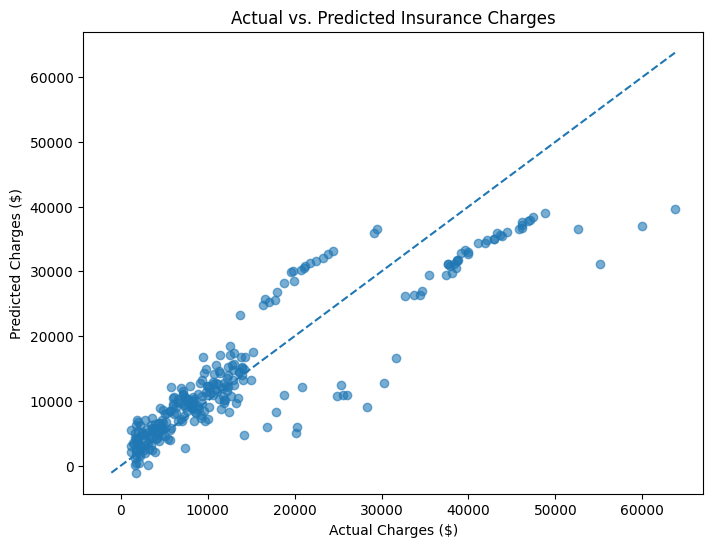

In [68]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect-prediction reference line
lower = min(y_test.min(), y_pred.min())
upper = max(y_test.max(), y_pred.max())

plt.plot(
    [lower, upper],
    [lower, upper],
    linestyle="--"
)

plt.title("Actual vs. Predicted Insurance Charges")
plt.xlabel("Actual Charges ($)")
plt.ylabel("Predicted Charges ($)")
plt.show()

In [69]:
# Build a table of actual and predicted charges
results = pd.DataFrame({
    "actual_charges": y_test,
    "predicted_charges": y_pred
})

results["residual"] = (
    results["actual_charges"]
    - results["predicted_charges"]
)

results["absolute_error"] = (
    results["residual"].abs()
)

results.head()

,actual_charges,predicted_charges,residual,absolute_error
900,"8,688.86","8,143.69",545.16,545.16
1064,"5,708.87","5,737.12",-28.25,28.25
1256,"11,436.74","14,369.31","-2,932.58","2,932.58"
298,"38,746.36","31,745.51","7,000.84","7,000.84"
237,"4,463.21","8,962.39","-4,499.18","4,499.18"


In [70]:
# Add the original test-set features
results["smoker"] = X_test["smoker"].values

error_by_smoker = (
    results.groupby("smoker")
    .agg(
        customers=("actual_charges", "count"),
        mean_actual=("actual_charges", "mean"),
        mean_predicted=("predicted_charges", "mean"),
        MAE=("absolute_error", "mean"),
        mean_residual=("residual", "mean")
    )
    .round(2)
)

error_by_smoker

,customers,mean_actual,mean_predicted,MAE,mean_residual
smoker,,,,,
no,208,"8,202.99","8,557.74","2,770.27",-354.74
yes,60,"35,311.26","32,182.00","9,053.87","3,129.26"


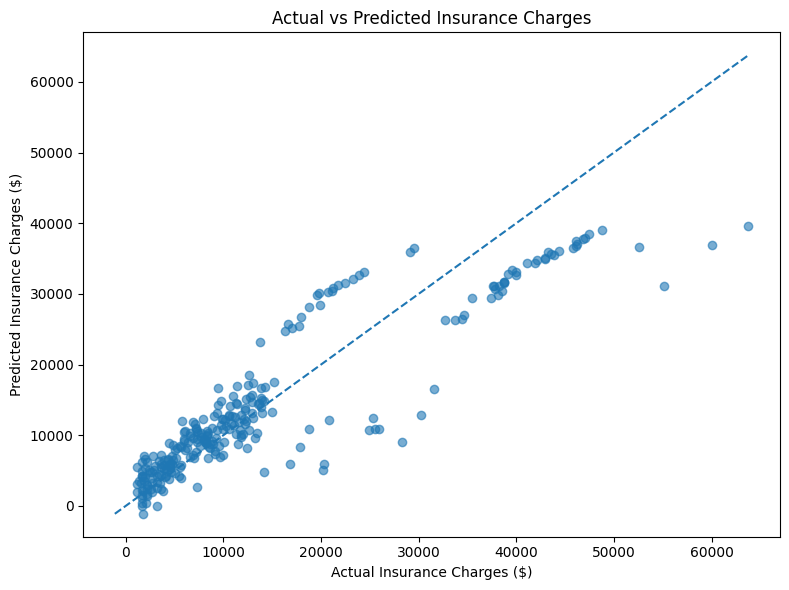

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

# Perfect-prediction reference line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Insurance Charges ($)")
plt.ylabel("Predicted Insurance Charges ($)")
plt.title("Actual vs Predicted Insurance Charges")
plt.tight_layout()
plt.show()

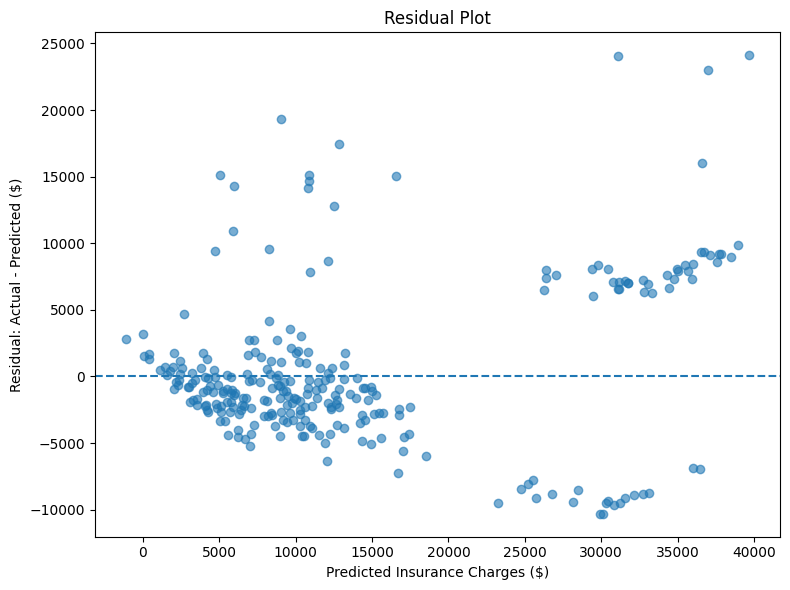

In [72]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    results["residual"],
    alpha=0.6
)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Insurance Charges ($)")
plt.ylabel("Residual: Actual - Predicted ($)")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

In [73]:
# Relative absolute error as a percentage of actual charges
results["absolute_percentage_error"] = (
    results["absolute_error"]
    / results["actual_charges"]
    * 100
)

error_summary = (
    results.groupby("smoker")
    .agg(
        customers=("actual_charges", "count"),
        MAE=("absolute_error", "mean"),
        median_absolute_error=("absolute_error", "median"),
        median_percentage_error=(
            "absolute_percentage_error", "median"
        )
    )
    .round(2)
)

error_summary

,customers,MAE,median_absolute_error,median_percentage_error
smoker,,,,
no,208,"2,770.27","1,881.49",29.07
yes,60,"9,053.87","8,361.01",20.63


In [74]:
# Create the final dataset for SQL and Power BI
df_final = df_clean.copy()

# Check the dataset size
print("Rows:", df_final.shape[0])
print("Columns:", df_final.shape[1])

# Display the first 5 rows
df_final.head()

Rows: 1337
Columns: 9


,age,sex,bmi,children,smoker,region,charges,age_group,bmi_category
0,19,female,27.90,0,yes,southwest,"16,884.92",18-25,Overweight
1,18,male,33.77,1,no,southeast,"1,725.55",18-25,Obese
2,28,male,33.00,3,no,southeast,"4,449.46",26-35,Obese
3,33,male,22.70,0,no,northwest,"21,984.47",26-35,Normal
4,32,male,28.88,0,no,northwest,"3,866.86",26-35,Overweight


In [75]:
# Check data types and non-null counts
df_final.info()

# Check missing values
print("\nMissing values per column:")
print(df_final.isnull().sum())

# Check duplicate rows
print("\nDuplicate rows:", df_final.duplicated().sum())

# Check categorical values
print("\nSmoking categories:")
print(df_final["smoker"].value_counts())

print("\nAge groups:")
print(df_final["age_group"].value_counts().sort_index())

print("\nBMI categories:")
print(df_final["bmi_category"].value_counts().sort_index())

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   age           1337 non-null   int64   
 1   sex           1337 non-null   object  
 2   bmi           1337 non-null   float64 
 3   children      1337 non-null   int64   
 4   smoker        1337 non-null   object  
 5   region        1337 non-null   object  
 6   charges       1337 non-null   float64 
 7   age_group     1337 non-null   category
 8   bmi_category  1337 non-null   category
dtypes: category(2), float64(2), int64(2), object(3)
memory usage: 86.6+ KB

Missing values per column:
age             0
sex             0
bmi             0
children        0
smoker          0
region          0
charges         0
age_group       0
bmi_category    0
dtype: int64

Duplicate rows: 0

Smoking categories:
smoker
no     1063
yes     274
Name: count, dtype: int64

Age groups:
age_group
18-25    305
26-

In [76]:
# Export the final dataset
df_final.to_csv("insurance_clean.csv", index=False)

print("CSV file created successfully!")

CSV file created successfully!


In [77]:
from google.colab import files

files.download("insurance_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [78]:
# Read the exported CSV back into Pandas
df_check = pd.read_csv("insurance_clean.csv")

print("Exported rows:", len(df_check))
print("Exported columns:", len(df_check.columns))
print("Duplicate rows:", df_check.duplicated().sum())

df_check.head()

Exported rows: 1337
Exported columns: 9
Duplicate rows: 0


,age,sex,bmi,children,smoker,region,charges,age_group,bmi_category
0,19,female,27.90,0,yes,southwest,"16,884.92",18-25,Overweight
1,18,male,33.77,1,no,southeast,"1,725.55",18-25,Obese
2,28,male,33.00,3,no,southeast,"4,449.46",26-35,Obese
3,33,male,22.70,0,no,northwest,"21,984.47",26-35,Normal
4,32,male,28.88,0,no,northwest,"3,866.86",26-35,Overweight
